# Movie Rating Prediction

### SoftGrowTech – Data Science Internship
### Task: Movie Rating Prediction

## 1. Project Overview

This project focuses on predicting movie ratings using machine learning techniques. The dataset contains information about movies such as year, duration, genre, metascore, votes, and other attributes.

The objective is to analyze the available movie features, preprocess the data, build regression models, and evaluate their performance in predicting IMDb movie ratings.

## 2. Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## 3. Load the Dataset

In [6]:
df = pd.read_csv("imdb-movies-dataset.csv")

df.head()

,Poster,Title,Year,Certificate,Duration (min),Genre,Rating,Metascore,Director,Cast,Votes,Description,Review Count,Review Title,Review
0,https://m.media-amazon.com/images/M/MV5BYWRkZj...,The Idea of You,2023.0,R,115.0,"Comedy, Drama, Romance",6.4,67.0,Michael Showalter,"Anne Hathaway, Nicholas Galitzine, Ella Rubin,...","28,744","Solène, a 40-year-old single mom, begins an un...",166,Hypocrisy as an idea,"This film, as well as the reaction to it, is a..."
1,https://m.media-amazon.com/images/M/MV5BZGI4NT...,Kingdom of the Planet of the Apes,2023.0,PG-13,145.0,"Action, Adventure, Sci-Fi",7.3,66.0,Wes Ball,"Owen Teague, Freya Allan, Kevin Durand, Peter ...","22,248","Many years after the reign of Caesar, a young ...",183,A phenomenal start to another trilogy!,"I'm a big fan of all the planet of the apes, a..."
2,https://m.media-amazon.com/images/M/MV5BZjIyOT...,Unfrosted,2023.0,PG-13,97.0,"Biography, Comedy, History",5.5,42.0,Jerry Seinfeld,"Isaac Bae, Jerry Seinfeld, Chris Rickett, Rach...","18,401","In 1963 Michigan, business rivals Kellogg's an...",333,not funny,Pretty much the worst criticism you can lay on...
3,https://m.media-amazon.com/images/M/MV5BMjA5Zj...,The Fall Guy,2023.0,PG-13,126.0,"Action, Comedy, Drama",7.3,73.0,David Leitch,"Ryan Gosling, Emily Blunt, Aaron Taylor-Johnso...","38,953",A down-and-out stuntman must find the missing ...,384,Everything you needed and more!,Just got out of the Austin premier at SXSW and...
4,https://m.media-amazon.com/images/M/MV5BNTk1MT...,Challengers,2023.0,R,131.0,"Drama, Romance, Sport",7.7,82.0,Luca Guadagnino,"Zendaya, Mike Faist, Josh O'Connor, Darnell Ap...","32,517","Tashi, a former tennis prodigy turned coach, t...",194,"Watch ""Match Point"" instead",This is a tough one. I liked the concept and t...


## 4. Dataset Inspection

Before preprocessing the data, the dataset is inspected to understand its dimensions, column names, data types, and overall structure.

In [7]:
df.shape

(10000, 15)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Poster          10000 non-null  str    
 1   Title           10000 non-null  str    
 2   Year            9850 non-null   float64
 3   Certificate     7370 non-null   str    
 4   Duration (min)  9664 non-null   float64
 5   Genre           9993 non-null   str    
 6   Rating          9596 non-null   float64
 7   Metascore       7555 non-null   float64
 8   Director        9995 non-null   str    
 9   Cast            9961 non-null   str    
 10  Votes           9596 non-null   str    
 11  Description     10000 non-null  str    
 12  Review Count    9999 non-null   str    
 13  Review Title    9483 non-null   str    
 14  Review          9484 non-null   str    
dtypes: float64(4), str(11)
memory usage: 1.1 MB


In [9]:
df.columns

Index(['Poster', 'Title', 'Year', 'Certificate', 'Duration (min)', 'Genre',
       'Rating', 'Metascore', 'Director', 'Cast', 'Votes', 'Description',
       'Review Count', 'Review Title', 'Review'],
      dtype='str')

In [10]:
df.describe()

,Year,Duration (min),Rating,Metascore
count,9850.000000,9664.000000,9596.000000,7555.000000
mean,2005.761421,108.809603,6.438610,58.068299
std,18.958005,23.159749,1.051412,17.845240
min,1929.000000,45.000000,1.300000,1.000000
25%,1997.000000,95.000000,5.800000,45.500000
50%,2012.000000,105.000000,6.500000,58.000000
75%,2021.000000,118.000000,7.200000,71.000000
max,2025.000000,746.000000,9.700000,100.000000


## 5. Checking Missing Values

Missing values are checked in each column to identify features that require cleaning or appropriate handling before model training.

In [11]:
df.isnull().sum()

Poster               0
Title                0
Year               150
Certificate       2630
Duration (min)     336
Genre                7
Rating             404
Metascore         2445
Director             5
Cast                39
Votes              404
Description          0
Review Count         1
Review Title       517
Review             516
dtype: int64

## 6. Checking Duplicate Records

Duplicate records are checked to ensure that repeated movie entries do not affect the analysis and model performance.

In [12]:
df.duplicated().sum()

np.int64(0)

## 7. Data Preprocessing

Data preprocessing is performed to prepare the dataset for machine learning. This includes handling missing values, converting text-based numerical columns into numeric format, and selecting relevant features for prediction.

In [13]:
df = df.dropna(subset=['Rating'])

df.shape

(9596, 15)

### 7.1 Converting Numerical Columns

The `Votes` and `Review Count` columns are stored as text values. They are converted into numeric format so they can be used as machine learning features.

In [14]:
df['Votes'] = pd.to_numeric(
    df['Votes'].str.replace(',', '', regex=False),
    errors='coerce'
)

df['Review Count'] = pd.to_numeric(
    df['Review Count'].str.replace(',', '', regex=False),
    errors='coerce'
)

df[['Votes', 'Review Count']].head()

,Votes,Review Count
0,28744,166.0
1,22248,183.0
2,18401,333.0
3,38953,384.0
4,32517,194.0


### 7.2 Rechecking Missing Values

After converting the text-based numerical columns, the missing values are checked again. This helps identify any additional missing values created during numeric conversion.

In [15]:
df.isnull().sum()

Poster               0
Title                0
Year               140
Certificate       2284
Duration (min)       9
Genre                0
Rating               0
Metascore         2041
Director             0
Cast                 7
Votes                0
Description          0
Review Count         1
Review Title       115
Review             114
dtype: int64

### 7.3 Selecting Relevant Features

Relevant numerical and categorical features are selected for predicting movie ratings. Text-heavy and identification-related columns are excluded because they are not directly suitable for the initial regression models.

In [16]:
features = [
    'Year',
    'Duration (min)',
    'Genre',
    'Certificate',
    'Metascore',
    'Votes',
    'Review Count'
]

target = 'Rating'

model_df = df[features + [target]].copy()

model_df.head()

,Year,Duration (min),Genre,Certificate,Metascore,Votes,Review Count,Rating
0,2023.0,115.0,"Comedy, Drama, Romance",R,67.0,28744,166.0,6.4
1,2023.0,145.0,"Action, Adventure, Sci-Fi",PG-13,66.0,22248,183.0,7.3
2,2023.0,97.0,"Biography, Comedy, History",PG-13,42.0,18401,333.0,5.5
3,2023.0,126.0,"Action, Comedy, Drama",PG-13,73.0,38953,384.0,7.3
4,2023.0,131.0,"Drama, Romance, Sport",R,82.0,32517,194.0,7.7


### 7.4 Handling Missing Values

Missing values in numerical features are handled using the median, while missing categorical values are replaced with the most frequent category. This approach helps retain useful records while preparing the data for machine learning.

In [17]:
numeric_features = [
    'Year',
    'Duration (min)',
    'Metascore',
    'Votes',
    'Review Count'
]

categorical_features = [
    'Genre',
    'Certificate'
]

for column in numeric_features:
    model_df[column] = model_df[column].fillna(model_df[column].median())

for column in categorical_features:
    model_df[column] = model_df[column].fillna(model_df[column].mode()[0])

model_df.isnull().sum()

Year              0
Duration (min)    0
Genre             0
Certificate       0
Metascore         0
Votes             0
Review Count      0
Rating            0
dtype: int64

## 8. Exploratory Data Analysis

Exploratory Data Analysis (EDA) is performed to understand the distribution of movie ratings and the relationships between important movie features before building the prediction models.

### 8.1 Distribution of Movie Ratings

The distribution of movie ratings is visualized to understand the overall rating pattern in the dataset.

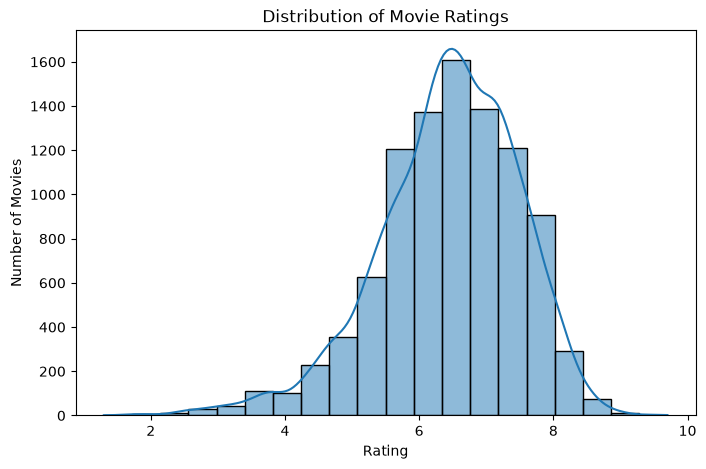

In [18]:
plt.figure(figsize=(8, 5))

sns.histplot(
    model_df['Rating'],
    bins=20,
    kde=True
)

plt.title('Distribution of Movie Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Movies')
plt.show()

### 8.2 Rating vs. Metascore

The relationship between IMDb ratings and Metascores is visualized using a scatter plot. This helps identify whether movies with higher critic scores tend to receive higher audience ratings.

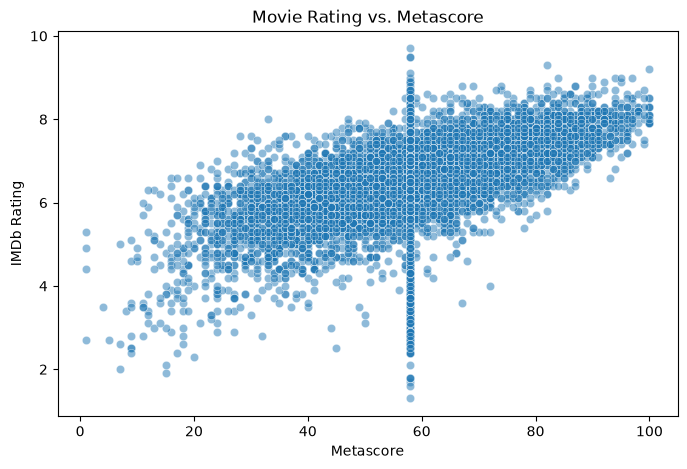

In [40]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=model_df,
    x='Metascore',
    y='Rating',
    alpha=0.5
)

plt.title('Movie Rating vs. Metascore')
plt.xlabel('Metascore')
plt.ylabel('IMDb Rating')
plt.show()

### 8.3 Rating vs. Number of Votes

The relationship between movie ratings and the number of votes is visualized to examine whether audience engagement is associated with movie ratings.

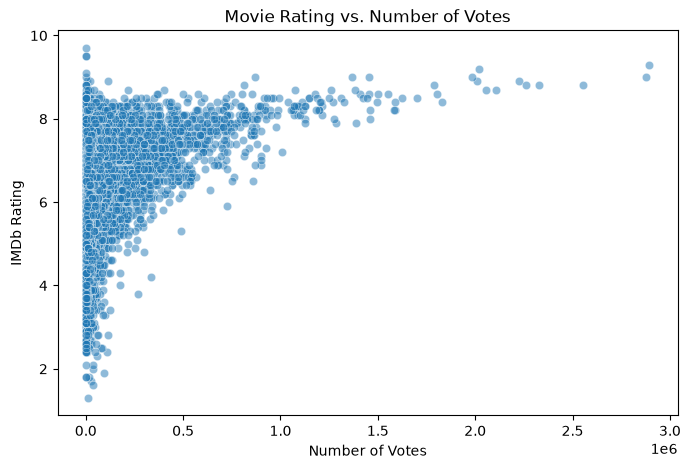

In [20]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=model_df,
    x='Votes',
    y='Rating',
    alpha=0.5
)

plt.title('Movie Rating vs. Number of Votes')
plt.xlabel('Number of Votes')
plt.ylabel('IMDb Rating')
plt.show()

### 8.4 Average Rating by Genre

The average rating of movies is compared across individual genres. Since some movies belong to multiple genres, the genre values are separated before calculating the average rating for each genre.

In [21]:
genre_df = model_df.copy()

genre_df['Genre'] = genre_df['Genre'].str.split(', ')

genre_df = genre_df.explode('Genre')

genre_ratings = (
    genre_df.groupby('Genre')['Rating']
    .mean()
    .sort_values(ascending=False)
)

genre_ratings

Genre
Film-Noir      7.675676
Documentary    7.307563
War            7.130612
Biography      7.080975
History        6.961371
Animation      6.854402
Western        6.803546
Music          6.723600
Drama          6.711173
Musical        6.654310
Sport          6.639196
Crime          6.575874
Romance        6.468858
Adventure      6.418969
Mystery        6.342085
Comedy         6.305381
Family         6.292375
Action         6.262113
Thriller       6.203629
Fantasy        6.196229
Sci-Fi         6.149266
Horror         5.859751
Name: Rating, dtype: float64

### 8.5 Average Rating by Genre Visualization

The average movie rating for each genre is visualized to make differences between genres easier to compare.

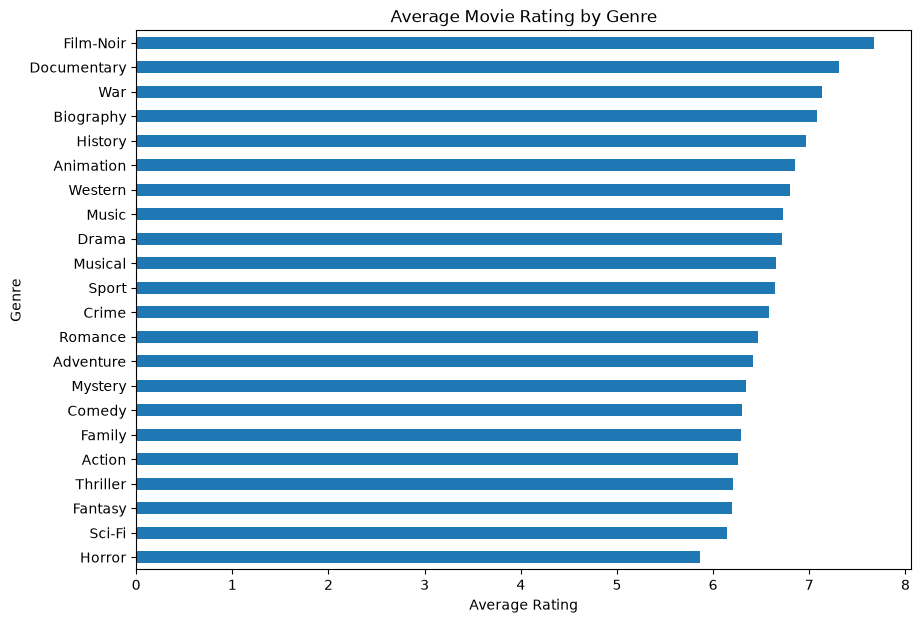

In [22]:
plt.figure(figsize=(10, 7))

genre_ratings.sort_values().plot(kind='barh')

plt.title('Average Movie Rating by Genre')
plt.xlabel('Average Rating')
plt.ylabel('Genre')
plt.show()

### 8.6 Correlation Analysis

Correlation analysis is used to examine the relationships between numerical movie features and the target rating. This helps identify which numerical variables may have stronger relationships with movie ratings.

In [23]:
correlation = model_df[
    ['Year', 'Duration (min)', 'Metascore', 'Votes', 'Review Count', 'Rating']
].corr()

correlation

,Year,Duration (min),Metascore,Votes,Review Count,Rating
Year,1.000000,0.006356,0.011461,0.028052,0.032942,0.013896
Duration (min),0.006356,1.000000,0.196547,0.229780,0.241109,0.359494
Metascore,0.011461,0.196547,1.000000,0.224085,0.116199,0.579340
Votes,0.028052,0.229780,0.224085,1.000000,0.687275,0.368872
Review Count,0.032942,0.241109,0.116199,0.687275,1.000000,0.222437
Rating,0.013896,0.359494,0.579340,0.368872,0.222437,1.000000


### 8.7 Correlation Heatmap

A correlation heatmap is used to visually represent the relationships among the numerical features and movie ratings. Higher positive values indicate stronger positive relationships.

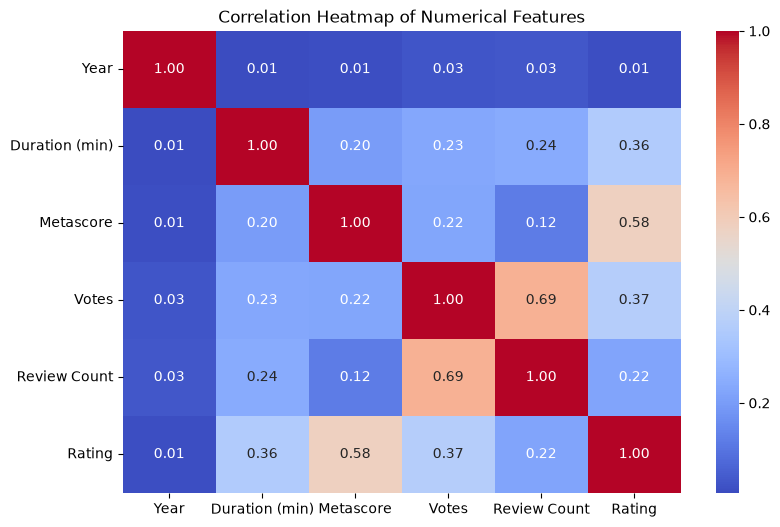

In [24]:
plt.figure(figsize=(9, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap of Numerical Features')
plt.show()

## 9. Preparing Data for Machine Learning

The processed dataset is divided into input features and the target variable. The data is then split into training and testing sets so that the models can be evaluated on unseen movie records.

In [25]:
X = model_df[features]
y = model_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (7676, 7)
Testing data shape: (1920, 7)


### 9.1 Feature Preprocessing

Numerical features are standardized using `StandardScaler`, while categorical features are converted into numerical form using one-hot encoding. A preprocessing pipeline is used to apply these transformations consistently to both training and testing data.

In [27]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

### 9.2 Linear Regression

Linear Regression is used as the first baseline model for predicting movie ratings. It establishes a reference point for comparing the performance of more advanced regression models.

In [28]:
linear_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LinearRegression())
    ]
)

linear_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['Year','Duration (min)','Genre',...,'Metascore','Votes','Review Count']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsi

### 9.3 Linear Regression Evaluation

The trained Linear Regression model is used to predict ratings for the testing dataset. Its performance is evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² Score.

In [29]:
y_pred_lr = linear_model.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Results")
print("MAE:", mae_lr)
print("RMSE:", rmse_lr)
print("R² Score:", r2_lr)

Linear Regression Results
MAE: 0.5471110515578281
RMSE: 0.7459816436521457
R² Score: 0.4890221168094192


### 9.4 Decision Tree Regression

A Decision Tree Regressor is trained to capture nonlinear relationships between movie features and ratings. Its performance will be compared with the Linear Regression baseline.

In [30]:
tree_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', DecisionTreeRegressor(
            random_state=42,
            max_depth=10
        ))
    ]
)

tree_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['Year','Duration (min)','Genre',...,'Metascore','Votes','Review Count']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsi

### 9.5 Decision Tree Evaluation

The trained Decision Tree Regressor is used to predict ratings on the testing dataset. Its performance is evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² Score.

In [31]:
y_pred_tree = tree_model.predict(X_test)

mae_tree = mean_absolute_error(y_test, y_pred_tree)
rmse_tree = np.sqrt(mean_squared_error(y_test, y_pred_tree))
r2_tree = r2_score(y_test, y_pred_tree)

print("Decision Tree Results")
print("MAE:", mae_tree)
print("RMSE:", rmse_tree)
print("R² Score:", r2_tree)

Decision Tree Results
MAE: 0.5646244746275695
RMSE: 0.7811282561733447
R² Score: 0.4397388387540595


### 9.6 Random Forest Regression

Random Forest Regression is used to improve prediction performance by combining multiple decision trees. It can capture complex nonlinear relationships between movie features and ratings while reducing the risk of overfitting compared with a single decision tree.

In [32]:
rf_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', RandomForestRegressor(
            n_estimators=100,
            random_state=42,
            max_depth=10,
            n_jobs=-1
        ))
    ]
)

rf_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['Year','Duration (min)','Genre',...,'Metascore','Votes','Review Count']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsi

### 9.7 Random Forest Evaluation

The trained Random Forest Regressor is used to predict movie ratings on the testing dataset. Its performance is evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² Score.

In [33]:
y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R² Score:", r2_rf)

Random Forest Results
MAE: 0.5117265203953772
RMSE: 0.7089194457943246
R² Score: 0.5385341157376266


### 9.8 Model Performance Comparison

The performance of all three regression models is compared using MAE, RMSE, and R² Score. Lower MAE and RMSE indicate better prediction accuracy, while a higher R² Score indicates better explanatory performance.

In [34]:
results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Decision Tree',
        'Random Forest'
    ],
    'MAE': [
        mae_lr,
        mae_tree,
        mae_rf
    ],
    'RMSE': [
        rmse_lr,
        rmse_tree,
        rmse_rf
    ],
    'R² Score': [
        r2_lr,
        r2_tree,
        r2_rf
    ]
})

results

,Model,MAE,RMSE,R² Score
0,Linear Regression,0.547111,0.745982,0.489022
1,Decision Tree,0.564624,0.781128,0.439739
2,Random Forest,0.511727,0.708919,0.538534


### 9.9 R² Score Comparison

The R² scores of the three regression models are visualized to compare how well each model explains the variation in movie ratings. A higher R² Score indicates better model performance.

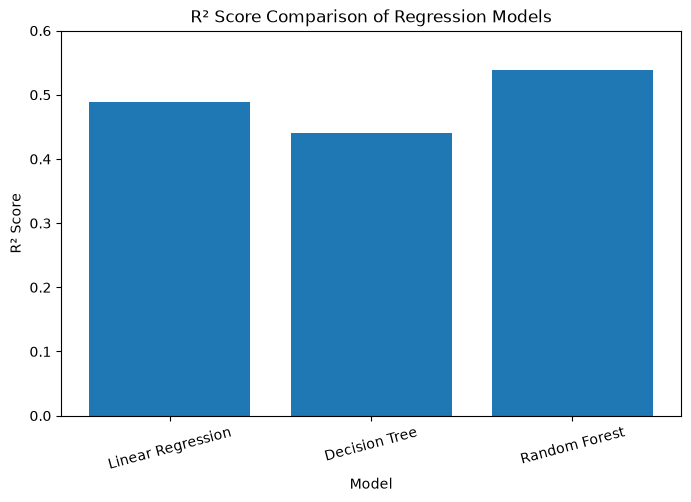

In [35]:
plt.figure(figsize=(8, 5))

plt.bar(
    results['Model'],
    results['R² Score']
)

plt.title('R² Score Comparison of Regression Models')
plt.xlabel('Model')
plt.ylabel('R² Score')
plt.ylim(0, 0.6)
plt.xticks(rotation=15)

plt.show()

## 10. Best Model Prediction Analysis

Based on the evaluation results, Random Forest Regression achieved the best overall performance. Its predictions are analyzed by comparing the actual movie ratings with the ratings predicted by the model.

In [36]:
prediction_comparison = pd.DataFrame({
    'Actual Rating': y_test.values,
    'Predicted Rating': y_pred_rf
})

prediction_comparison.head(10)

,Actual Rating,Predicted Rating
0,7.0,7.460527
1,7.1,6.673771
2,7.6,5.375754
3,5.6,6.201899
4,6.7,7.019249
5,7.6,6.978084
6,6.7,6.893173
7,7.3,7.574170
8,5.8,6.990571
9,6.1,6.390049


### 10.1 Actual vs. Predicted Ratings

The actual IMDb ratings are compared with the ratings predicted by the Random Forest model. A scatter plot is used to visually assess how closely the predictions follow the actual ratings.

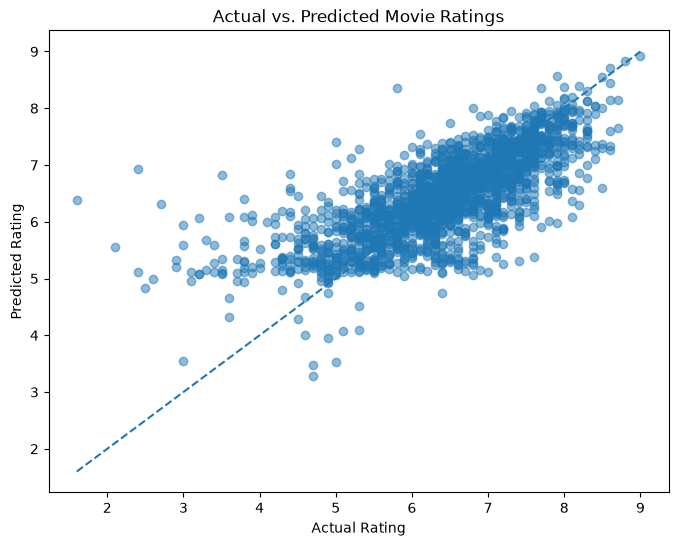

In [37]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_rf,
    alpha=0.5
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)

plt.title('Actual vs. Predicted Movie Ratings')
plt.xlabel('Actual Rating')
plt.ylabel('Predicted Rating')

plt.show()

## 11. Final Results and Findings

The three regression models were evaluated using MAE, RMSE, and R² Score. Among the tested models, Random Forest Regression achieved the best overall performance.

### Key Findings

- Random Forest achieved the lowest MAE of **0.512**, indicating the smallest average prediction error.
- Random Forest achieved the lowest RMSE of **0.709**, showing better overall prediction accuracy.
- Random Forest achieved the highest R² Score of **0.539**, explaining approximately **53.9% of the variation** in movie ratings.
- Linear Regression performed better than the Decision Tree model on this dataset.
- Metascore showed the strongest numerical correlation with IMDb Rating, with a correlation of approximately **0.58**.
- Genre analysis showed that **Film-Noir** had the highest average rating, while **Horror** had the lowest average rating in this dataset.

## 13. Future Improvements

The performance of the movie rating prediction system can be improved through the following approaches:

- Apply hyperparameter tuning to optimize the regression models.
- Use log transformations for highly skewed features such as Votes and Review Count.
- Improve genre representation by encoding individual genres instead of treating combined genre labels as single categories.
- Include additional movie features such as Director, Cast, and Certificate details.
- Apply advanced ensemble models such as Gradient Boosting or XGBoost.
- Perform feature importance analysis to identify the most influential factors affecting movie ratings.
- Increase the dataset size and use more diverse movie information to improve model generalization.